###Estatística descritiva

Em sua essência, a estatística é a ciência que apresenta processos próprios para coletar, apresentar e interpretar adequadamente conjuntos de dados, sejam eles numéricos ou não. Pode-se dizer que seu objetivo é o de apresentar informações sobre dados em análise para que se tenha maior compreensão dos fatos que os mesmos representam.

A estatística descritiva, como o próprio nome já diz, se preocupa em descrever os dados.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

####Medidas de tendência central

As medidas de tendência central são assim denominadas por indicarem um ponto em torno do qual se concetram os dados


#####Média aritmética

A média aritmética (x) é a soma de todos os valores observados da variável dividida pelo número total de obserevações 

In [2]:
base_dados = sns.load_dataset('iris')
base_dados.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
base_dados.shape

(150, 5)

In [4]:
base_dados['petal_length'].mean()

np.float64(3.7580000000000005)

####Moda

A moda (Mo) é o valor que apresenta a maior fequência de variável entre os valores observados

In [5]:
base_dados['petal_length'].mode()

0    1.4
1    1.5
Name: petal_length, dtype: float64

####Mediana

A mediana (Md) é o valor que ocupa a posição central da série de observações de uma variável, em rol, dividindo o conjunto em duas partes iguais, ou seja, a quantidade de valores inferiores à mediana é igual à quantidade de valores superiores a mesma.

In [6]:
base_dados['petal_length'].median()

4.35

###Módulo 2 - Medidas Separatrizes

Estas medidas são valores que ocupam posições no conjunto de dados, em rol, dividindo-se em partes iguais e podem ser:

1. Quartil: O quartis dividem o conjunto de dados em quatro partes iguais

|Estatística|Notação|Interpretação|Poisção|
|:--:|:---:|:----|:---:|
|1° quartil|Q1|25% dos dados são valores menores ou iguais ao valor do 1° quartil|p=0,25(n+1)|
|2° Quartil|Q2=Me|50% dos dados são valores menores ou iguais ao valor do segundo quartil|p=0,50(n+1)|
|3° Quadril|Q3|75% dos dados são valores menores ou iguais ao valor do terceiro quartil|p=0,75(n+1)|

In [7]:
base_dados['petal_length'].describe()

count    150.000000
mean       3.758000
std        1.765298
min        1.000000
25%        1.600000
50%        4.350000
75%        5.100000
max        6.900000
Name: petal_length, dtype: float64

<Axes: ylabel='petal_length'>

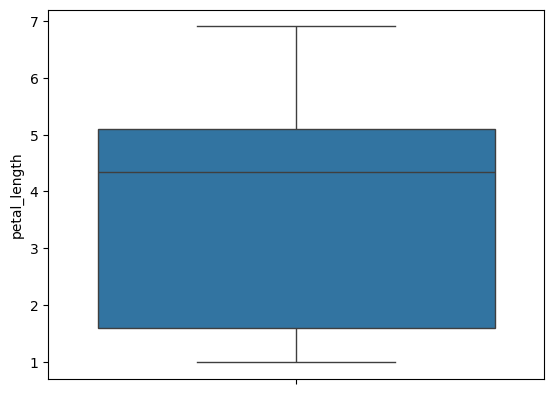

In [8]:
sns.boxplot(base_dados['petal_length'])

###Módulo 3 - Medidas de dispersão

As medidas de dispersão auxiliam as medidas de tendência central e descrever o conjunto de dados adequademento. Indicam se os dados estão, ou não, próximos uns dos outros.

Amplitude Total

A amplitude total de um conjunto de dados é a difereça entre o maior e o menor valor observado

In [10]:
base_dados['sepal_length'].max() - base_dados['sepal_length'].min()

3.6000000000000005

Amplitude Interquartílica

A amplitude interquartílica é a diferença entre o terceiro e o primeiro quartil. Esta medida é mais estável que a amplitude total por não considerar os valores mais extremos

In [15]:
base_dados['sepal_length'].describe()[6:7]

75%    6.4
Name: sepal_length, dtype: float64

In [16]:
base_dados['sepal_length'].describe()[6:7].values - base_dados['sepal_length'].describe()[4:5].values

array([1.3])

Amplitude semi-interquartílica

A amplitude semi-interquartílica é definida como a média aritmética da diferença entre a mediana e os quartis

In [18]:
(base_dados['sepal_length'].describe()[6:7].values - base_dados['sepal_length'].describe()[4:5].values)/2

array([0.65])

Variência

Uma medida de dispersão que mostra quão distantes os valores estão da média

In [19]:
base_dados['sepal_length'].var()

0.6856935123042505

Desvio padrão

É simplesmente o resultado positivo da raiz quadrada da variância

In [20]:
base_dados['sepal_length'].std()

0.8280661279778629

Medidas de Assimetria

A medida de assimetria é um indicador da forma distribuição dos dados. Ao construir uma distribuição de frequências e/ou um histograma, está-se buscando, também, identificar visualmente, a forma da distribuição dos dados

- Simétrica se -> média = mediana = moda ou AS = 0
- Assimétrica negativa se -> média =< mediana =< moda As < 0
- Assimétrica positiva se -> moda =< mediana =< média

In [ ]:
base_dados['sepal_length'].skew() #Cálculo da assimetria

np.float64(0.3149109566369728)

<Axes: xlabel='sepal_length', ylabel='Density'>

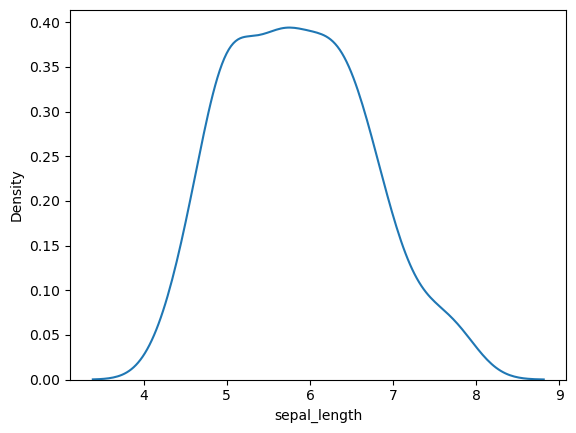

In [22]:
sns.kdeplot(base_dados['sepal_length'])

Medidas de Custose

A medida de curtose é o grau de achatamento da distribuição, é um indicador da forma desta distribuição

- Leptocúrtica: quando a distribuição apresenta uma curva de frequência bastante fechada, com os dados fortemente concentrados em torno de seu centro, K < 0,263

- Mesocúrtica: quando os dados estão razoavelmente concentrados em torno de seu centro, K = 0,263

- Platicúrtica: quando adistribuição apresenta uma curva de frequência mais aberta, com os dados fracamente concentrados em torno de seu centro, K > 0,263

In [23]:
base_dados['sepal_length'].kurtosis()

np.float64(-0.5520640413156395)

###Módulo 4 - Correlação

Quando fazer análise de corrrelação?

Quando você tem uma hipótese de que o aumento ou queda em uma variável estão associados à evolução de outra variável, por exemplo, se aumentar o desconto, as vendas também aumentam.

Correlação de Pearson

O coeficiente de correlação de Pearson pode ter um intervalo de valores de +1 a -1. 
- Um valor de 0 indica que não há associação entre as duas variáveis. 
- Um valor maior que 0 indica uma associação positiva. Isto é, à medida que o valor de uma variável aumenta, o mesmo acontece com o valor da outra variável. 
- Um valor menor que 0 indica uma associação negativa. Isto é, à medida que o valor de uma variável aumenta, o valor da outra diminui.

In [27]:
base_dados.corr(numeric_only=True)

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


<Axes: >

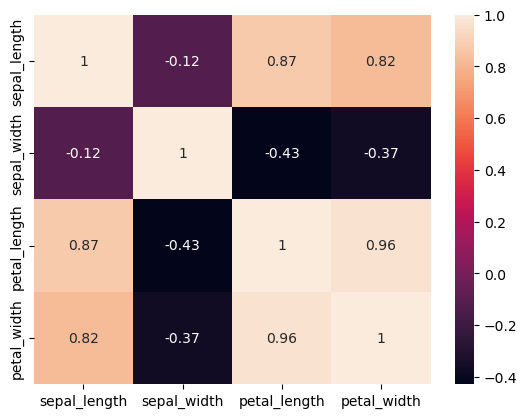

In [29]:
sns.heatmap(base_dados.corr(numeric_only=True), annot=True)

<Axes: xlabel='petal_length', ylabel='petal_width'>

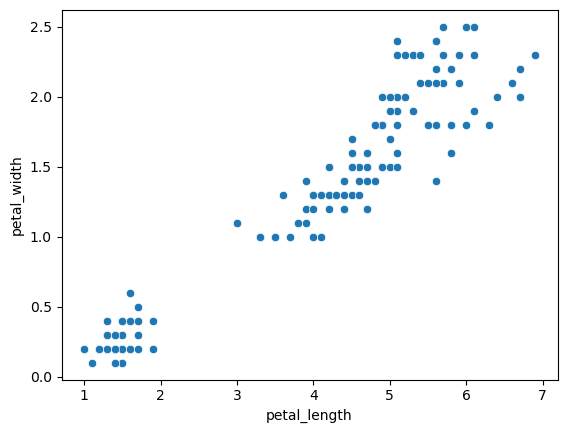

In [30]:
sns.scatterplot(data=base_dados, x='petal_length', y='petal_width')

Correlação de Spearman

Uma vez que a correlação de Spearman segue uma lógica monotética, e não tem pressupostos lineares como na correlação de Pearson, é possível utilizar o rs para relações não lineares

In [32]:
base_dados.corr('spearman', numeric_only=True)

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.166778,0.881898,0.834289
sepal_width,-0.166778,1.000000,-0.309635,-0.289032
petal_length,0.881898,-0.309635,1.000000,0.937667
petal_width,0.834289,-0.289032,0.937667,1.000000


<Axes: >

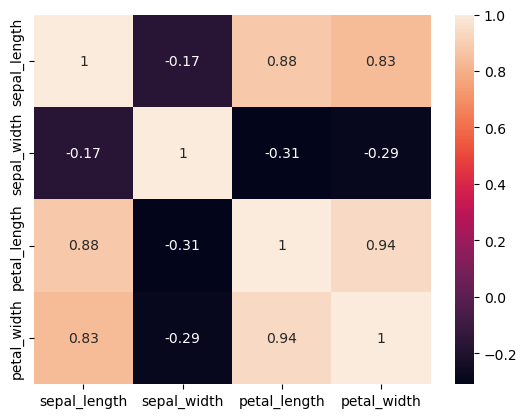

In [33]:
sns.heatmap(base_dados.corr('spearman', numeric_only=True), annot=True)

<Axes: xlabel='sepal_length', ylabel='petal_width'>

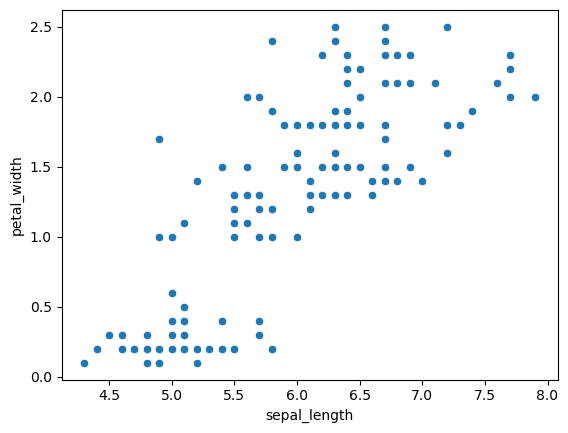

In [36]:
sns.scatterplot(data=base_dados, x='sepal_length', y='petal_width')